In [ ]:
!pip install torch torchvision torchaudio datasets open3d wandb numpy tqdm huggingface_hub

In [ ]:
import os
import glob
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import open3d as o3d
import wandb

from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

In [ ]:
CFG = {
    "voxel_size": 64,
    "data_dir": "data/raw_10k",
    "batch_size": 4,
    "epochs": 200,
    "lr": 1e-4,
    "latent_dim": 256
}

In [ ]:
import os
from huggingface_hub import hf_hub_download
import glob
import zipfile
os.makedirs("data", exist_ok=True)

print("📥 Downloading raw point clouds (10k points per plant)...")
zip_path = hf_hub_download(
    repo_id="BGLab/MaizeField3D",
    filename="datasets/FielGrwon_ZeaMays_RawPCD_10k.zip",
    repo_type="dataset",
    local_dir="data"
)
print(f"✅ Downloaded: {zip_path}")

print("📦 Extracting...")
with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(CFG["data_dir"])

ply_files = sorted(glob.glob(f"{CFG['data_dir']}/**/*.ply", recursive=True))
print(f"✅ Found {len(ply_files)} plant files.")

📥 Downloading raw point clouds (10k points per plant)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


datasets/FielGrwon_ZeaMays_RawPCD_10k.zi(…):   0%|          | 0.00/218M [00:00<?, ?B/s]

✅ Downloaded: data/datasets/FielGrwon_ZeaMays_RawPCD_10k.zip
📦 Extracting...
✅ Found 1045 plant files.


In [ ]:
class MaizeVoxelDataset(Dataset):

    def __init__(self, ply_files, grid_size=64):

        self.files = ply_files
        self.grid_size = grid_size

    def normalize(self, points):

        centroid = np.mean(points, axis=0)
        points = points - centroid

        scale = np.max(np.linalg.norm(points, axis=1))
        points = points / scale

        return points

    def voxelize(self, points):

        grid = np.zeros((self.grid_size,
                         self.grid_size,
                         self.grid_size))

        coords = (points + 1) / 2
        coords = coords * (self.grid_size - 1)
        coords = coords.astype(int)

        coords = np.clip(coords, 0, self.grid_size - 1)

        grid[coords[:,0], coords[:,1], coords[:,2]] = 1

        return grid

    def __len__(self):

        return len(self.files)

    def __getitem__(self, idx):

        path = self.files[idx]

        pcd = o3d.io.read_point_cloud(path)
        points = np.asarray(pcd.points)

        points = self.normalize(points)

        voxels = self.voxelize(points)

        voxels = torch.tensor(voxels, dtype=torch.float32)

        voxels = voxels.unsqueeze(0)

        return voxels

In [ ]:
dataset = MaizeVoxelDataset(
    ply_files,
    grid_size=CFG["voxel_size"]
)

loader = DataLoader(
    dataset,
    batch_size=CFG["batch_size"],
    shuffle=True
)

In [ ]:
class VoxelEncoder(nn.Module):

    def __init__(self, latent_dim=256):

        super().__init__()

        self.conv = nn.Sequential(

            nn.Conv3d(1, 32, 4, stride=2, padding=1),
            nn.ReLU(),

            nn.Conv3d(32, 64, 4, stride=2, padding=1),
            nn.ReLU(),

            nn.Conv3d(64, 128, 4, stride=2, padding=1),
            nn.ReLU(),

            nn.Conv3d(128, 256, 4, stride=2, padding=1),
            nn.ReLU()
        )

        self.fc = nn.Linear(256 * 4 * 4 * 4, latent_dim)

    def forward(self, x):

        x = self.conv(x)

        x = x.view(x.size(0), -1)

        z = self.fc(x)

        return z

In [ ]:
class VoxelDecoder(nn.Module):

    def __init__(self, latent_dim=256):

        super().__init__()

        self.fc = nn.Linear(latent_dim, 256 * 4 * 4 * 4)

        self.deconv = nn.Sequential(

            nn.ConvTranspose3d(256,128,4,stride=2,padding=1),
            nn.ReLU(),

            nn.ConvTranspose3d(128,64,4,stride=2,padding=1),
            nn.ReLU(),

            nn.ConvTranspose3d(64,32,4,stride=2,padding=1),
            nn.ReLU(),

            nn.ConvTranspose3d(32,1,4,stride=2,padding=1),
            nn.Sigmoid()
        )

    def forward(self, z):

        x = self.fc(z)

        x = x.view(-1,256,4,4,4)

        x = self.deconv(x)

        return x

In [ ]:
class VoxelAutoencoder(nn.Module):

    def __init__(self, latent_dim=256):

        super().__init__()

        self.encoder = VoxelEncoder(latent_dim)
        self.decoder = VoxelDecoder(latent_dim)

    def forward(self, x):

        z = self.encoder(x)

        recon = self.decoder(z)

        return recon, z

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = VoxelAutoencoder(
    latent_dim=CFG["latent_dim"]
).to(device)

optimizer = optim.Adam(model.parameters(), lr=CFG["lr"])

criterion = nn.BCELoss()

In [ ]:
wandb.login()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: ghosalsohom2003 (ghosalsohom2003-own-use) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [ ]:
wandb.init(
    project="maize-voxel-autoencoder",
    config=CFG
)

100%|██████████| 262/262 [00:13<00:00, 19.77it/s]


Epoch 0 | Loss 0.2975384455977562


100%|██████████| 262/262 [00:11<00:00, 23.12it/s]


Epoch 1 | Loss 0.015130122636537287


100%|██████████| 262/262 [00:11<00:00, 23.72it/s]


...

Epoch 197 | Loss 0.0010571284286272605


100%|██████████| 262/262 [00:11<00:00, 22.17it/s]


Epoch 198 | Loss 0.0010512128015997897


100%|██████████| 262/262 [00:11<00:00, 22.75it/s]


Epoch 199 | Loss 0.0010385495694514137


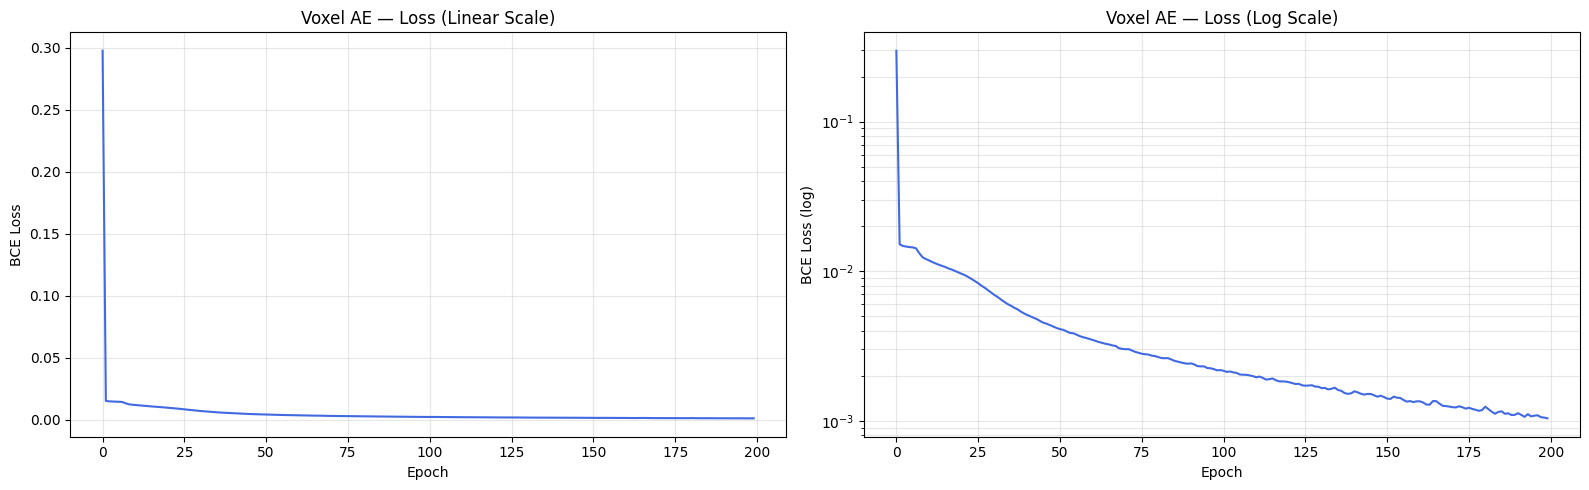

In [ ]:
import math
import matplotlib.pyplot as plt

try:
    import plotly.graph_objects as go
except ImportError:
    !pip install plotly -q
    import plotly.graph_objects as go

all_losses = []

for epoch in range(CFG["epochs"]):

    model.train()

    total_loss = 0

    for voxels in tqdm(loader):

        voxels = voxels.to(device)

        recon, _ = model(voxels)

        loss = criterion(recon, voxels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(loader)
    all_losses.append(avg_loss)

    log_loss = math.log10(avg_loss) if avg_loss > 0 else -10

    wandb.log({
        "epoch": epoch,
        "loss": avg_loss,
        "loss_log": log_loss
    })

    print(f"Epoch {epoch} | Loss {avg_loss}")

# ── Loss curves — LOG SCALE in both Colab and W&B ─────────────────────
epochs_x = list(range(len(all_losses)))

# --- Colab: matplotlib ---
fig_mpl, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

ax1.plot(epochs_x, all_losses, color='royalblue', linewidth=1.5)
ax1.set_xlabel("Epoch"); ax1.set_ylabel("BCE Loss")
ax1.set_title("Voxel AE — Loss (Linear Scale)"); ax1.grid(True, alpha=0.3)

ax2.plot(epochs_x, all_losses, color='royalblue', linewidth=1.5)
ax2.set_yscale('log')
ax2.set_xlabel("Epoch"); ax2.set_ylabel("BCE Loss (log)")
ax2.set_title("Voxel AE — Loss (Log Scale)"); ax2.grid(True, alpha=0.3, which='both')

plt.tight_layout(); plt.show()

# --- W&B: Plotly log-scale ---
fig_log = go.Figure()
fig_log.add_trace(go.Scatter(
    x=epochs_x, y=all_losses, mode='lines',
    name='BCE Loss', line=dict(color='royalblue', width=2)
))
fig_log.update_layout(
    title="Voxel AE — Training Loss (Log Scale)",
    xaxis_title="Epoch", yaxis_title="BCE Loss",
    yaxis_type="log", template="plotly_dark"
)
fig_log.show()
wandb.log({"loss_curve_log": wandb.Plotly(fig_log)})

# Linear version to W&B too
fig_lin = go.Figure()
fig_lin.add_trace(go.Scatter(
    x=epochs_x, y=all_losses, mode='lines',
    name='BCE Loss', line=dict(color='royalblue', width=2)
))
fig_lin.update_layout(
    title="Voxel AE — Training Loss (Linear Scale)",
    xaxis_title="Epoch", yaxis_title="BCE Loss",
    template="plotly_dark"
)
wandb.log({"loss_curve_linear": wandb.Plotly(fig_lin)})

🔍 Reconstruction check (4 random plants):

  Sample 287 | input pts:   884 | recon pts:   856 | IoU: 0.9016
  Sample 575 | input pts:  1042 | recon pts:  1064 | IoU: 0.8787
  Sample 175 | input pts:   939 | recon pts:   917 | IoU: 0.8824
  Sample 479 | input pts:   612 | recon pts:   600 | IoU: 0.8938


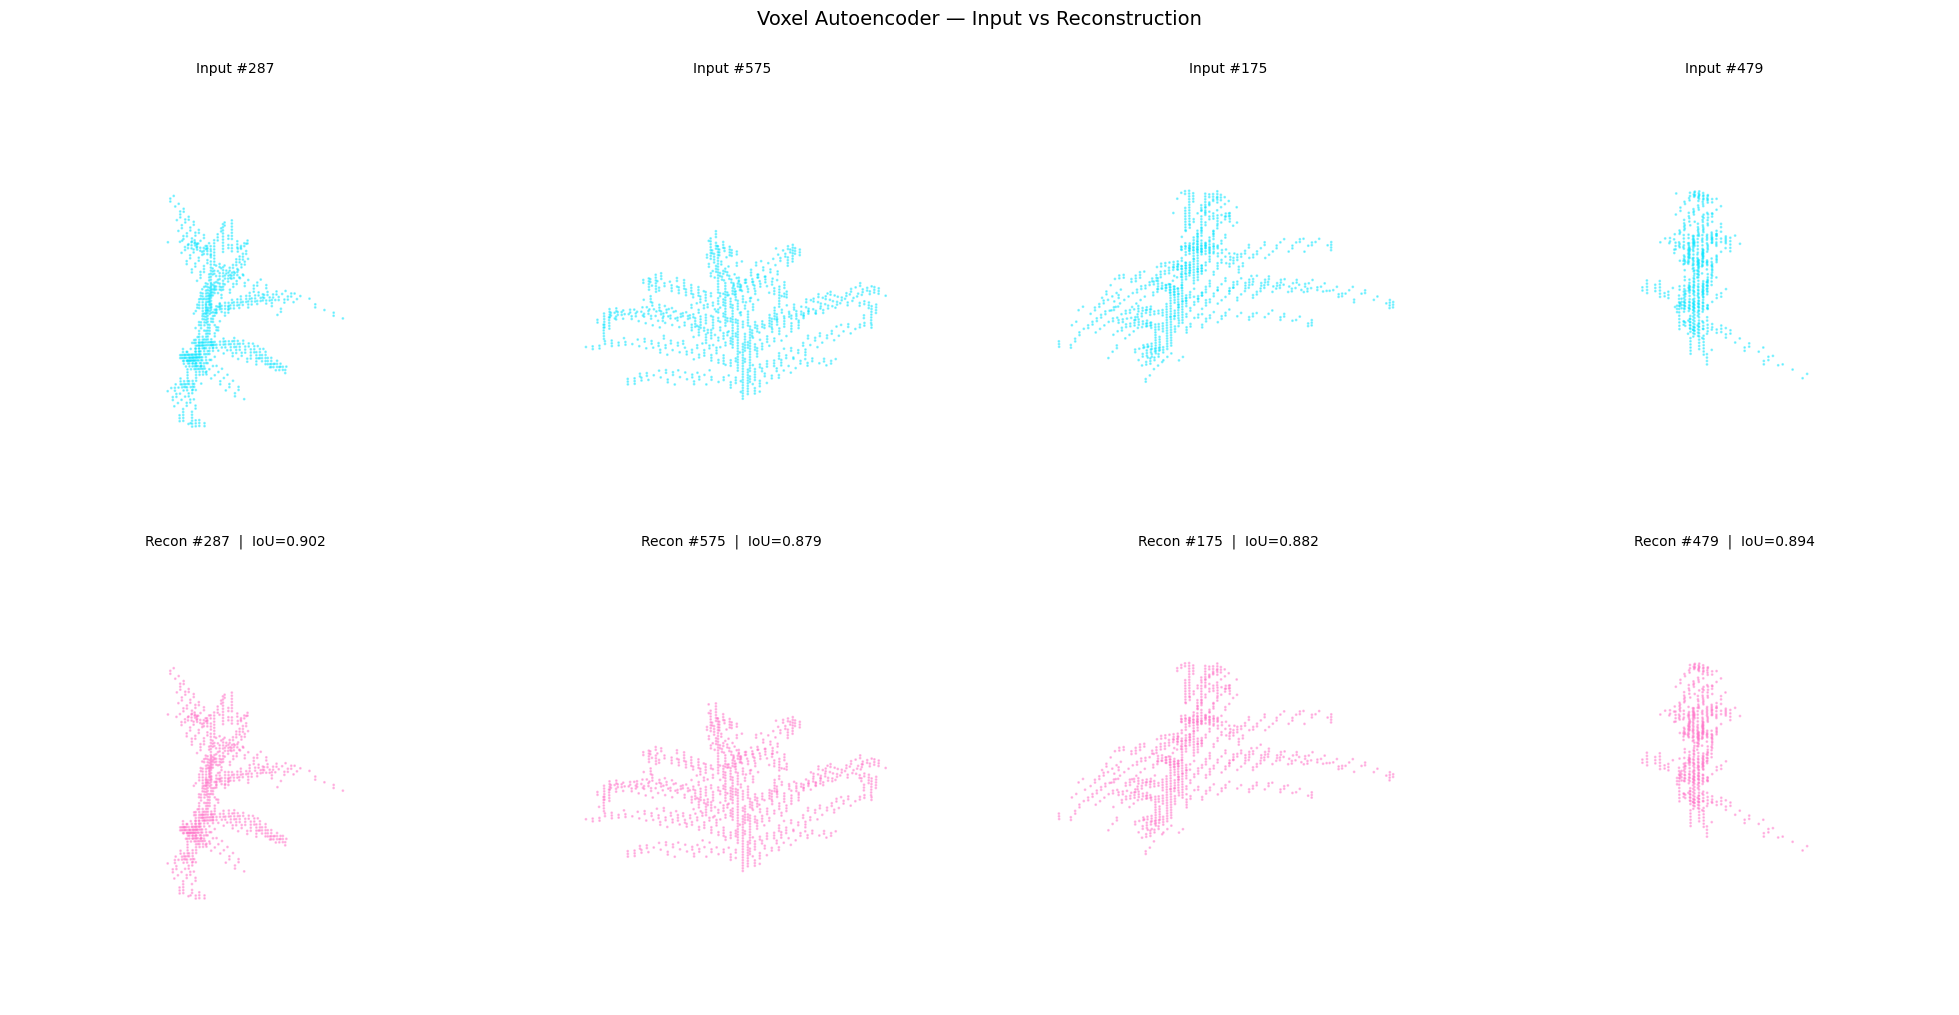

In [ ]:
# ============================================================
# RECONSTRUCTION VISUALIZATION
# ============================================================
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import torch

def voxel_to_pointcloud(voxel_grid, threshold=0.5):
    """Convert a voxel grid (1, D, H, W) → (N, 3) point array."""
    # squeeze out batch + channel dims → (D, H, W)
    grid = voxel_grid.squeeze().cpu().numpy()
    # get indices of occupied voxels
    coords = np.argwhere(grid > threshold)          # shape (N, 3)
    # normalize to [-1, 1] to match training space
    coords = coords / (grid.shape[0] - 1) * 2 - 1
    return coords


def visualize_reconstruction(model, dataset, device, num_samples=4, threshold=0.5, save_path=None):
    """
    For `num_samples` plants, show:
      - Input voxel occupancy (as a 3D scatter)
      - Reconstructed voxel occupancy
      - IoU score between them
    """
    model.eval()

    # ── pick random samples ────────────────────────────────
    indices = np.random.choice(len(dataset), num_samples, replace=False)

    fig = plt.figure(figsize=(5 * num_samples, 10))
    fig.suptitle("Voxel Autoencoder — Input vs Reconstruction", fontsize=14, y=1.01)

    for col, idx in enumerate(indices):
        voxel = dataset[idx].unsqueeze(0).to(device)      # (1, 1, D, H, W)

        with torch.no_grad():
            recon, z = model(voxel)                        # recon: (1, 1, D, H, W)

        # ── convert to point clouds ────────────────────────
        input_pts  = voxel_to_pointcloud(voxel,  threshold)
        recon_pts  = voxel_to_pointcloud(recon,  threshold)

        # ── IoU ───────────────────────────────────────────
        input_bin = (voxel.squeeze().cpu().numpy()  > threshold).astype(bool)
        recon_bin = (recon.squeeze().cpu().numpy()  > threshold).astype(bool)
        intersection = (input_bin & recon_bin).sum()
        union        = (input_bin | recon_bin).sum()
        iou = intersection / union if union > 0 else 0.0

        # ── plot input ─────────────────────────────────────
        ax1 = fig.add_subplot(2, num_samples, col + 1, projection='3d')
        if len(input_pts) > 0:
            ax1.scatter(
                input_pts[:, 0], input_pts[:, 1], input_pts[:, 2],
                s=1, c='#00e5ff', alpha=0.4, rasterized=True
            )
        ax1.set_title(f"Input #{idx}", fontsize=10)
        ax1.set_axis_off()

        # ── plot reconstruction ────────────────────────────
        ax2 = fig.add_subplot(2, num_samples, num_samples + col + 1, projection='3d')
        if len(recon_pts) > 0:
            ax2.scatter(
                recon_pts[:, 0], recon_pts[:, 1], recon_pts[:, 2],
                s=1, c='#ff6ec7', alpha=0.4, rasterized=True
            )
        ax2.set_title(f"Recon #{idx}  |  IoU={iou:.3f}", fontsize=10)
        ax2.set_axis_off()

        print(f"  Sample {idx:>3} | input pts: {len(input_pts):>5} | "
              f"recon pts: {len(recon_pts):>5} | IoU: {iou:.4f}")

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"\n💾 Saved to {save_path}")

    plt.show()


def log_reconstruction_to_wandb(model, dataset, device, num_samples=4, threshold=0.5):
    """Log input/recon side-by-side panels to W&B as a single image."""
    import wandb
    import tempfile, os

    tmp = tempfile.mktemp(suffix=".png")
    visualize_reconstruction(model, dataset, device,
                             num_samples=num_samples,
                             threshold=threshold,
                             save_path=tmp)
    wandb.log({"reconstructions": wandb.Image(tmp)})
    os.remove(tmp)
    print("✅ Logged to W&B")


# ── RUN ───────────────────────────────────────────────────────
print("🔍 Reconstruction check (4 random plants):\n")
visualize_reconstruction(
    model, dataset, device,
    num_samples=4,
    threshold=0.5
)

# optionally log to W&B (call after training loop)
# log_reconstruction_to_wandb(model, dataset, device)

  Sample 498 | input pts:   746 | recon pts:   740 | IoU: 0.8954
  Sample 853 | input pts:   795 | recon pts:   779 | IoU: 0.8987
  Sample 421 | input pts:   583 | recon pts:   568 | IoU: 0.8900
  Sample 580 | input pts:   755 | recon pts:   750 | IoU: 0.8742

💾 Saved to /tmp/tmpjlaa3gg_.png


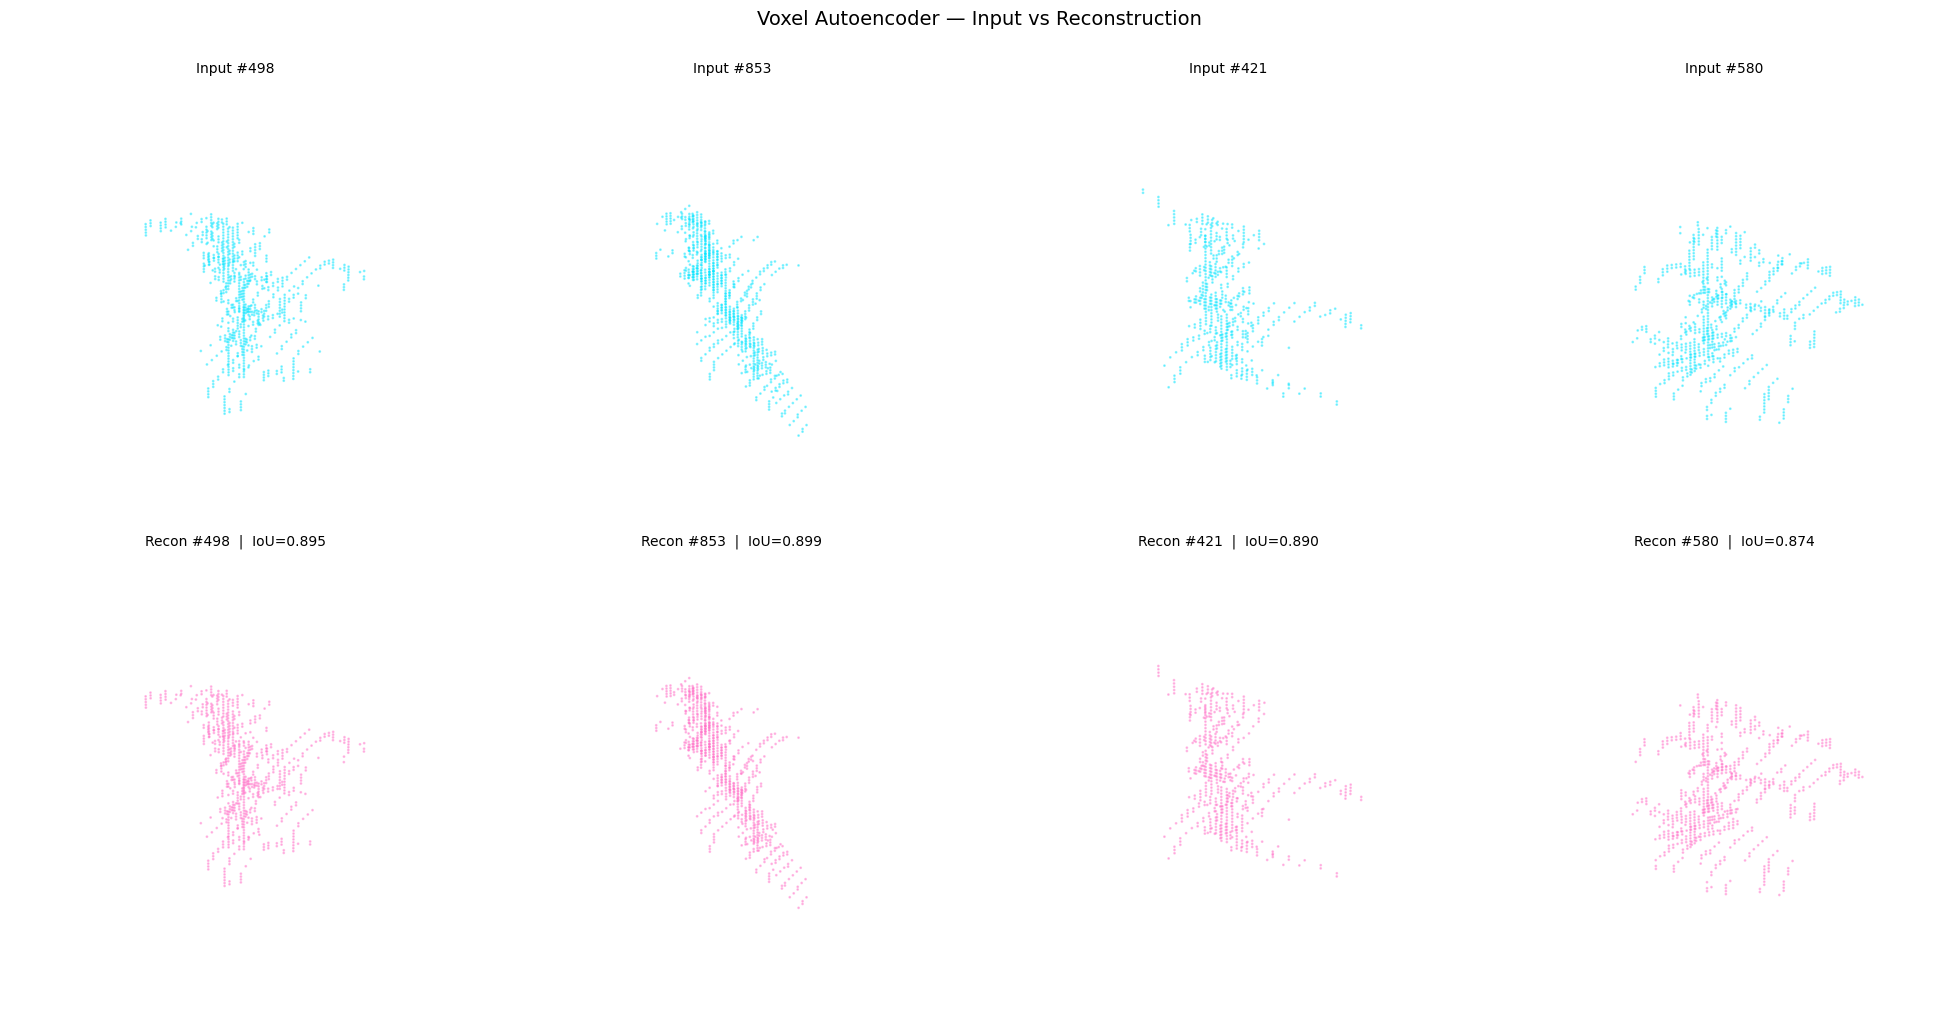

✅ Logged to W&B


In [ ]:
log_reconstruction_to_wandb(model, dataset, device)